In [1]:
import collections
import gc
import itertools
import os
import sys
sys.path.append("/workspace/mta_vision_transformers/")
from collections import OrderedDict
from typing import Any, Callable, Dict, Iterable, List, Set, Tuple

import numpy as np
import einops
import torch
import torch.nn as nn
import torch.nn.functional as Fn
import torch.utils.data
from matplotlib import pyplot as plt
from tensordict import TensorDict
from torch.utils._pytree import tree_flatten

from core.monitor import Monitor
from infrastructure import utils
from infrastructure.settings import DEVICE, OUTPUT_DEVICE, DTYPE
from dataset.construct import ImageDataset
from dataset.library import DATASETS


dataset_name, n_classes = DATASETS["Common"][1]
OUTPUT_DIR = "experiments/attention"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
# Ocean: 901085904
# Rose: 100390212
torch.set_printoptions(linewidth=400, sci_mode=False)

Seed: 1149496617


In [2]:
from modeling.vit_attention import OpenCLIPAttentionViT
from visualize.base import construct_per_layer_output_dict


# SECTION: Set up model
torch.set_default_device(DEVICE)
model = OpenCLIPAttentionViT({}, stop_layer=None).to(DEVICE)


# SECTION: Set up monitor
def residual_hook_fn(model_: nn.Module, input_: Any, output_: Any) -> Any:
    return input_ + tree_flatten(output_)[0][0]
    
def input_hook_fn(model_: nn.Module, input_: Any, output_: Any) -> Any:
    return tree_flatten(input_)[0][0]

def mean_attention_matrix_hook_fn(model_: nn.Module, input_: Any, output_: Any) -> Any:
    return torch.mean(einops.rearrange(
        tree_flatten(output_)[0][0],
        "b h n1 n2 -> b n1 n2 h"
    ), dim=-1).to(OUTPUT_DEVICE)

def attention_matrix_hook_fn(model_: nn.Module, input_: Any, output_: Any) -> Any:
    return einops.rearrange(
        tree_flatten(output_)[0][0],
        "b h n1 n2 -> b n1 n2 h"
    ).to(OUTPUT_DEVICE)
    
def get_weight_by_name(name: str) -> Callable[[nn.Module, Any, Any], Any]:
    def hook(model_: nn.Module, input_: Any, output_: Any) -> Any:
        return utils.rgetattr(model_, name).data
    return hook


monitor_config = OrderedDict({
    "model.visual.transformer.resblocks": OrderedDict({
        "": [
            ("layer_input", input_hook_fn),
            ("layer_output", Monitor.default_hook_fn),
        ],
        "attn": {
            # "": "attention_output",
            "return_attn_matrix": [
                ("attention_matrix", mean_attention_matrix_hook_fn),
            ],
            "return_unmasked_attn_matrix": [
                ("unmasked_attention_matrix", mean_attention_matrix_hook_fn)
            ],
        },
        "ln_1": "attention_input",  # "norm1"
        # "ln_2": [
        #     ("intermediate_output", input_hook_fn),
        # ],
        # "mlp": "mlp_output"
    })
})

monitor = Monitor(model, monitor_config)
model_weights_config = OrderedDict({
    "attn": OrderedDict({
        "in_proj_weight": "QKVw",
        "in_proj_bias": "QKVb",
        "out_proj.weight": "out_w",
        "out_proj.bias": "out_b",
    })
})


# SECTION: Set up dataset
batch_size = 50
dataset = ImageDataset(dataset_name, split="train", return_original_image=True)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator(DEVICE))
original_images, images = next(iter(dataloader))
# original_images, images = torch.flip(original_images, dims=[0]), torch.flip(images, dims=[0])


# SECTION: Run baseline model
per_metric_output_dict = monitor.reset()
with torch.no_grad():
    output = model.forward(images)

per_layer_output_dict: List[TensorDict] = construct_per_layer_output_dict(per_metric_output_dict)
model_weights: List[Dict[str, torch.Tensor]] = [{
    v: resblock.get_parameter(k).data
    for k, v in utils.flatten_nested_dict(model_weights_config).items()
} for resblock in model.get_submodule("model.visual.transformer.resblocks")]

/tmp/ipykernel_97416/394876694.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  artifact_mask: torch.Tensor = torch.load(f"experiments/saved_masks/ranked_AS_mask{batch_s

	Image 0 --- CLS attention: 0.10106483846902847, [0.2791488766670227, 0.19634510576725006, 0.01992950588464737, 0.014997943304479122, 0.014933007769286633]
	Image 1 --- CLS attention: 0.07485419511795044, [0.2636089026927948, 0.19319432973861694, 0.08652262389659882, 0.018743718042969704, 0.015619965270161629]
	Image 2 --- CLS attention: 0.11383522301912308, [0.2538546025753021, 0.22178292274475098, 0.04852762818336487, 0.01568472385406494, 0.008137174881994724]
	Image 3 --- CLS attention: 0.08890463411808014, [0.37577083706855774, 0.09584089368581772, 0.02104562148451805, 0.011884251609444618, 0.008227420970797539]


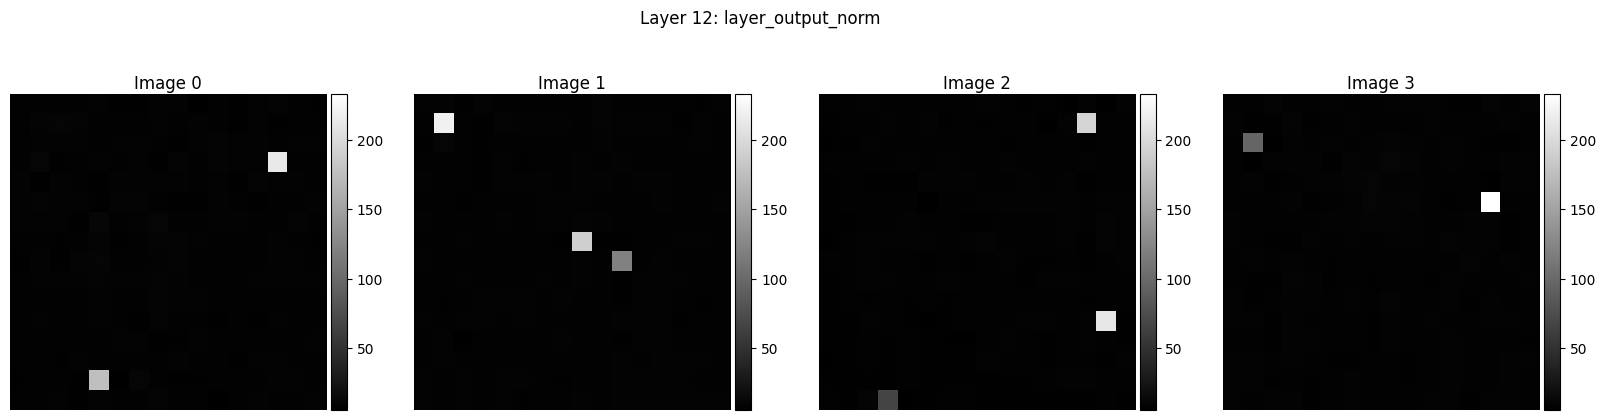

MA: 129/12850
Artifact: 12850/12850


/tmp/ipykernel_97416/394876694.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rgb_assignment = torch.load(rgb_fname, map_location=OUTPUT_DEVICE)


In [3]:
# SECTION: Visualize original images
%matplotlib inline
from modeling.image_features import ImageFeatures
from core.attention_sink import mask_attention_sink
from visualize.base import (
    visualize_images_with_mta,
    visualize_feature_norms_per_image,
    get_rgb_colors,
)

torch.set_default_device(OUTPUT_DEVICE)

# SECTION: Massive token heuristic
detection_layer = 13

artifact_mask: torch.Tensor = torch.load(f"experiments/saved_masks/ranked_AS_mask{batch_size}.pt", map_location=OUTPUT_DEVICE) > 0
mta_masks: Dict[int, torch.Tensor] = {
    "MA": mask_attention_sink(
        per_layer_output_dict[detection_layer]["attention_matrix"],
        max_num_tokens=None, scale=0.4, verbose=True
    ),
    "Artifact": artifact_mask
}
features = ImageFeatures(per_layer_output_dict, mta_masks, "default", DEVICE)
visualize_feature_norms_per_image(features, 12, "layer_output", cmap="gray")

for k, v in mta_masks.items():
    print(f"{k}: {v.sum().item()}/{v.numel()}")


# # SECTION: Visualize images
# for mask in mta_masks.values():
#     visualize_images_with_mta(original_images.to(OUTPUT_DEVICE), mask.to(OUTPUT_DEVICE))

try:
    rgb_assignment
except NameError:
    rgb_fname = "sandbox/rgb_assignment.pt"
    if not os.path.exists(rgb_fname):
        color_layer_idx = 10    # min(mta_masks.keys())
        rgb_assignment = get_rgb_colors(features, color_layer_idx, "layer_output", False)
        torch.save(rgb_assignment, rgb_fname)
    else:
        rgb_assignment = torch.load(rgb_fname, map_location=OUTPUT_DEVICE)

# highlight = torch.LongTensor((
#     (1, 5, 4),
#     (4, 15, 8),
# ))
# highlight = torch.load(f"{OUTPUT_DIR}/artifact_indices.pt")

In [4]:
# %matplotlib inline
# from dataclasses import dataclass
# from core.attention_sink import mask_attention_sink
# from modeling.image_features import ImageFeatures
# from visualize.base import (
#     VISUALIZED_INDICES,
#     construct_per_layer_output_dict,
#     visualize_features_per_image,
#     visualize_feature_norms_per_image,
#     visualize_feature_dot_products_per_image,
# )
# from visualize.attention import (
#     visualize_attention_matrix_per_image,
#     visualize_attention_suppression_per_image,
#     visualize_incoming_attention_per_image,
# )
# from visualize.projections import (
#     visualize_feature_values_by_pca,
# )


# for layer_idx in range(9, 13):
#     print(f"Layer {layer_idx} {'=' * 120}")
#     visualize_feature_dot_products_per_image(features, layer_idx, "layer_input", "attention_output")
#     visualize_feature_dot_products_per_image(features, layer_idx, "intermediate_output", "mlp_output")
#     visualize_feature_dot_products_per_image(features, layer_idx, "attention_output", "mlp_output")

In [5]:
# %matplotlib inline
# from dataclasses import dataclass
# from core.attention_sink import mask_attention_sink
# from modeling.image_features import ImageFeatures
# from visualize.base import (
#     VISUALIZED_INDICES,
#     construct_per_layer_output_dict,
#     visualize_features_per_image,
#     visualize_feature_norms_per_image,
# )
# from visualize.attention import (
#     visualize_attention_matrix_per_image,
#     visualize_attention_suppression_per_image,
#     visualize_incoming_attention_per_image,
# )
# from visualize.projections import (
#     visualize_feature_values_by_pca,
# )


# plotting_kwargs: Dict[str, Any] = {
#     "transform_func": None,
#     "order_by_tsne": False,
#     "per_head": False,
#     "rescale_func": lambda t: torch.log2(t + 1),
#     "global_cmap": False,
#     "cmap_scale": "linear",
#     "subsample": 1.0,
#     "spacing": 0.1,
#     "cmap": "viridis",
# }
# for layer_idx in range(ImageFeatures.NUM_LAYERS):
#     visualize_attention_suppression_per_image(
#         features=features,
#         layer_idx=layer_idx,
#         model_weights=model_weights,
#         empirical=True,
#         normalize=False,
#         name_to_mask=mta_masks,
#         pairwise=True,
#         **plotting_kwargs
#     )

In [1]:
%matplotlib inline
from dataclasses import dataclass
from core.attention_sink import mask_attention_sink
from modeling.image_features import ImageFeatures
from visualize.base import (
    VISUALIZED_INDICES,
    construct_per_layer_output_dict,
    visualize_features_per_image,
    visualize_feature_norms_per_image,
)
from visualize.attention import (
    visualize_attention_matrix_per_image,
    visualize_attention_suppression_per_image,
    visualize_incoming_attention_per_image,
)
from visualize.projections import (
    visualize_feature_values_by_pca,
)


@dataclass
class ModelLog:
    start: int = None
    end: int = None
    model: OpenCLIPAttentionViT = None
    mask_config: Dict[int, Tuple[OpenCLIPAttentionViT.ModeOptions, OpenCLIPAttentionViT.MaskOptions]] = None
    attn_out_proj_bias: bool = None
    monitor: Monitor = None
    per_metric_output_dict: OrderedDict[str, np.ndarray[List[torch.Tensor]]] = None
    per_layer_output_dict: List[Dict[str, np.ndarray[torch.Tensor]]] = None

save_experiment = False
mode = "mask"
mask_type = "X -> T"
mask_layer = 10
test_layer = 15

use_cls_proxy = False
use_cached_train = True
if use_cls_proxy:
    attn_matrix_func: Callable[[torch.Tensor], torch.Tensor] = lambda t: t[:, 0, :]
else:
    attn_matrix_func: Callable[[torch.Tensor], torch.Tensor] = lambda t: t
    # attn_matrix_func: Callable[[torch.Tensor], torch.Tensor] = lambda t: torch.mean(t, dim=1)

attention_matrix: torch.Tensor = per_layer_output_dict[detection_layer]["attention_matrix"].to(DEVICE)
# visualize_attention_matrix_per_image(detection_layer, attention_matrix, mta_masks, **plotting_kwargs)
# visualize_attention_suppression_per_image(
#     features=features,
#     layer_idx=10,
#     model_weights=model_weights,
#     empirical=False,
#     normalize=False,
#     name_to_mask=mta_masks,
#     pairwise=True,
#     **plotting_kwargs
# )
# raise Exception()
# visualize_incoming_attention_per_image(detection_layer, attention_matrix, cmap="gray")

highlight_mask = torch.full((batch_size, ImageFeatures.N + 1), False)
highlight_mask[:, [67, 126, 222]] = True
# for c in [(3, 67), (3, 126), (3, 222)]:
#     highlight_mask[c] = True

fname = f"{OUTPUT_DIR}/ranked_AS_mask.pt"
if save_experiment and os.path.exists(fname):
    ranked_AS_mask: torch.Tensor = torch.load(fname, map_location=OUTPUT_DEVICE)

else:
    attention_matrix_monitor_config = OrderedDict({
        "model.visual.transformer.resblocks": OrderedDict({
            "": [
                # ("layer_input", input_hook_fn),
                ("layer_output", Monitor.default_hook_fn),
            ],
            # "ln_1": "attention_input",  # "norm1"
            "attn": {
                # "": "attention_output",
                "return_attn_matrix": [
                    ("attention_matrix", mean_attention_matrix_hook_fn),
                ],
                "return_unmasked_attn_matrix": [
                    ("unmasked_attention_matrix", mean_attention_matrix_hook_fn)
                ],
            },
            "ln_2": [
                ("intermediate_output", input_hook_fn),
            ],
        })
    })
    
    continuation_layer: int = mask_layer + 1
    model_dict: Dict[str, ModelLog] = {
        "train": ModelLog(start=mask_layer, end=detection_layer, mask_config={
            i: (mode, mask_type)
            for i in range(mask_layer, ImageFeatures.NUM_LAYERS)
        }, attn_out_proj_bias=True),
        # "test": ModelLog(start=detection_layer, end=test_layer),
        "test": ModelLog(start=mask_layer, end=detection_layer, mask_config={
            i: (mode, mask_type) if i < continuation_layer else ("sink", "X -> X")
            for i in range(mask_layer, ImageFeatures.NUM_LAYERS)
        }, attn_out_proj_bias=True),
        # "test": ModelLog(start=mask_layer, end=detection_layer, mask_config={
        #     i: ("sink", "~T -> T")
        #     for i in range(mask_layer, ImageFeatures.NUM_LAYERS)
        # })
    }
    
    if use_cached_train:
        del model_dict["train"]
    
    for k, log in model_dict.items():
        log.model = OpenCLIPAttentionViT(mask_config=log.mask_config, attn_out_proj_bias=log.attn_out_proj_bias, stop_layer=log.end + 1)
        log.monitor = Monitor(log.model, attention_matrix_monitor_config)
    # new_model = OpenCLIPAttentionViT(mode, mask_type, {9, 10}, stop_layer=stop_layer).to(DEVICE)
   
    AS_mask: torch.Tensor = torch.full((batch_size, ImageFeatures.N + 1), False)
    ranked_AS_mask: torch.Tensor = torch.full((batch_size, ImageFeatures.N + 1), torch.inf)
    
    if use_cached_train:
        saved_ranked_AS_mask: torch.Tensor = torch.load("experiments/saved_masks/ranked_AS_mask50.pt", map_location=OUTPUT_DEVICE)
    else:
        saved_ranked_AS_mask: torch.Tensor = None
    
    with torch.no_grad():
        attention_dict: Dict[str, Dict[int, List[torch.Tensor]]] = {k: {} for k in model_dict.keys()}
        
        it, max_it, start_vis_it = 1, 2, 1
        convergence = torch.full((batch_size,), False)
        while not torch.all(convergence) and it <= max_it:
            s = "".join("\u25A0" if c else "\u25A1" for c in convergence)    
            print("=" * 160)
            print(f"Iteration {it}: {s}")
            print("=" * 160)
            
            torch.set_default_device(DEVICE)
            for log in model_dict.values():
                log.per_metric_output_dict = log.monitor.reset()
                # log.model.load_cache({"mask": mta_masks["Artifact"], "layer_output": [d["layer_output"] for d in per_layer_output_dict[:log.start]]})
                log.model.load_cache({"mask": AS_mask, "layer_output": [d["layer_output"] for d in per_layer_output_dict[:log.start]]})
                log.model.forward(images)
                log.per_layer_output_dict = construct_per_layer_output_dict(log.per_metric_output_dict)
            torch.set_default_device(OUTPUT_DEVICE)

            for k, log in model_dict.items():
                for layer_idx in range(log.start, log.end + 1):
                    attention_dict[k].setdefault(layer_idx, []).append(attn_matrix_func(log.per_metric_output_dict["unmasked_attention_matrix"][layer_idx][-1]))

            if use_cached_train:
                new_MA_mask = (saved_ranked_AS_mask == it)
            else:
                # SECTION: Massive token heuristic
                unmasked_attention_matrix: torch.Tensor = model_dict["train"].per_metric_output_dict["unmasked_attention_matrix"][detection_layer][-1].to(DEVICE)
                new_MA_mask = mask_attention_sink(model_dict["train"].per_metric_output_dict["attention_matrix"][detection_layer].pop(), max_num_tokens=1, masked_tokens=AS_mask, verbose=True)
            
            # SECTION: Visualize the attention matrix before and after
            if it >= start_vis_it:
                print(f"\tNumber of masked MAs: {torch.sum(AS_mask, dim=1)[VISUALIZED_INDICES].tolist()}")
                print(f"\tNumber of new MAs: {torch.sum(new_MA_mask, dim=1)[VISUALIZED_INDICES].tolist()}")
                
                for k, log in model_dict.items():
                    print(f"{k}:")
                    k_features = ImageFeatures(log.per_layer_output_dict, {}, "default", DEVICE)
                    
                    # visualize_attention_matrix_per_image(
                    #     detection_layer, unmasked_attention_matrix, collections.OrderedDict([
                    #         ("Masked", AS_mask),
                    #         ("Artifact", mta_masks["Artifact"]),
                    #         # "Highlight": highlight_mask,
                    #     ]), **plotting_kwargs,
                    # )
                    # visualize_attention_matrix_per_image(
                    #     detection_layer, unmasked_attention_matrix, collections.OrderedDict([
                    #         ("Masked", AS_mask),
                    #         ("AS", new_MA_mask),
                    #         # "MA": mta_masks["MA"],
                    #         ("Artifact", mta_masks["Artifact"]),
                    #         # "Highlight": highlight_mask,
                    #     ]), **plotting_kwargs,
                    # )
                    # visualize_incoming_attention_per_image(detection_layer, new_attention_matrix, cmap="gray", global_cmap=False)
                    
                    # new_features = ImageFeatures(model_dict["train"].per_layer_output_dict, {}, "default", DEVICE)
                    visualize_feature_norms_per_image(
                        features, mask_layer - 1, "layer_output",
                        global_cmap=False, write_values=True, cmap="gray", cmap_scale="log",
                    )
                    # visualize_feature_values_by_pca(
                    #     features, detection_layer - 1, "layer_output", {"linear"}, AS_mask, rgb_assignment,
                    #     ndim=2, with_cls=True,
                    # )
                    for layer_idx in range(mask_layer, detection_layer - 1): 
                        visualize_feature_norms_per_image(
                            k_features, layer_idx, "intermediate_output",
                            global_cmap=False, write_values=True, cmap="gray",
                        )
                        # visualize_feature_values_by_pca(
                        #     features, detection_layer - 1, "layer_output", {"linear"}, AS_mask, rgb_assignment,
                        #     ndim=2, with_cls=True,
                        # )
                        visualize_feature_norms_per_image(
                            k_features, layer_idx, "layer_output",
                            global_cmap=False, write_values=True, cmap="gray",  # cmap_scale="log",
                        )
                    # visualize_attention_suppression_per_image(
                    #     features=features,
                    #     layer_idx=10,
                    #     model_weights=model_weights,
                    #     empirical=False,
                    #     normalize=True,
                    #     name_to_mask=collections.OrderedDict([
                    #         ("Masked", AS_mask),
                    #         # "MA": mta_masks["MA"],
                    #         ("Artifact", mta_masks["Artifact"]),
                    #         # "Highlight": highlight_mask,
                    #     ]),
                    #     **plotting_kwargs
                    # )
                    # visualize_attention_suppression_per_image(
                    #     features=features,
                    #     layer_idx=10,
                    #     model_weights=model_weights,
                    #     empirical=False,
                    #     normalize=True,
                    #     name_to_mask=collections.OrderedDict([
                    #         ("Masked", AS_mask),
                    #         ("AS", new_MA_mask),
                    #         # "MA": mta_masks["MA"],
                    #         ("Artifact", mta_masks["Artifact"]),
                    #         # "Highlight": highlight_mask,
                    #     ]),
                    #     **plotting_kwargs
                    # )
                    
                    # visualize_features_per_image(features, 19, "layer_output", mta_mask=AS_mask, highlight=new_MA_mask)
                    # visualize_feature_norms_per_image(
                    #     new_features, detection_layer - 1, "layer_output",
                    #     global_cmap=False, write_values=True, cmap="gray",
                    # )
                    
                    
                    # test_features = ImageFeatures(model_dict["test"].per_layer_output_dict, {}, "default", DEVICE)
                    # visualize_feature_norms_per_image(
                    #     test_features, detection_layer - 1, "layer_output",
                    #     global_cmap=False, write_values=True, cmap="gray",
                    # )
                    # visualize_feature_values_by_pca(
                    #     new_features, detection_layer - 1, "layer_output", {"linear"}, AS_mask, rgb_assignment,
                    #     ndim=2, with_cls=True,
                    # )
            
            # SECTION: Update the cumulative MA mask with the new attention sinks
            AS_mask = AS_mask + new_MA_mask
            ranked_AS_mask[new_MA_mask] = it
            it += 1
            
            # SECTION: Check convergence
            convergence = torch.sum(new_MA_mask, dim=1) == 0
            
            # SECTION: Cleanup
            for log in model_dict.values():
                log.per_metric_output_dict = None
                log.per_layer_output_dict = None
                
            torch.cuda.empty_cache()
            gc.collect()

    attentions: Dict[str, Dict[int, torch.Tensor]] = {k: {_k: torch.stack(_v, dim=1) for _k, _v in v.items()} for k, v in attention_dict.items()}

    # SECTION: Save results
    if save_experiment:
        torch.save(ranked_AS_mask, fname)
AS_mask: torch.Tensor = torch.isfinite(ranked_AS_mask)

ModuleNotFoundError: No module named 'core'

In [ ]:
raise Exception()

In [ ]:
%matplotlib inline
from modeling.image_features import ImageFeatures
from visualize.base import (
    construct_per_layer_output_dict,
    visualize_feature_norms_per_image,
)


model_dict: Dict[str, ModelLog] = {
    "train": ModelLog(start=mask_layer, end=detection_layer),
    # "test": ModelLog(start=detection_layer, end=test_layer),
}
for k, log in model_dict.items():
    log.model = OpenCLIPAttentionViT(mode, mask_type, range(log.start, ImageFeatures.NUM_LAYERS), stop_layer=log.end + 1)
    log.monitor = Monitor(log.model, attention_matrix_monitor_config)


n_search = 5
topk_indices = torch.topk(ranked_AS_mask, dim=1, k=n_search + 1).indices

truth_table = torch.full((1 << n_search, n_search), False)
output_table = torch.zeros((1 << n_search, batch_size))

for i, bit_mask in enumerate(itertools.product(*((False, True) for _ in range(n_search)))):
    print(f"Bit mask: {bit_mask}")
    mask = torch.full((batch_size, ImageFeatures.N + 1), False)
    mask[torch.arange(batch_size)[:, None], topk_indices[:, :-1]] = torch.tensor(bit_mask)
    
    with torch.no_grad():
        torch.set_default_device(DEVICE)
        for log in model_dict.values():
            log.per_metric_output_dict = log.monitor.reset()
            log.model.load_cache({"mask": mask, "layer_output": [d["layer_output"] for d in per_layer_output_dict[:log.start]]})
            log.model.forward(images)
            log.per_layer_output_dict = construct_per_layer_output_dict(log.per_metric_output_dict)
        torch.set_default_device(OUTPUT_DEVICE)

    new_features = ImageFeatures(model_dict["train"].per_layer_output_dict, {}, "default", DEVICE)
    # visualize_feature_norms_per_image(
    #     new_features, detection_layer - 1, "layer_output",
    #     global_cmap=False, write_values=True, cmap="gray",
    # )
    feature_norms = torch.norm(new_features.get(layer_idx=detection_layer - 1, key="layer_output", include=(ImageFeatures.CLS, ImageFeatures.IMAGE,), with_batch=True), p=2, dim=-1)
    
    truth_table[i] = torch.tensor(bit_mask)
    output_table[i] = feature_norms[torch.arange(batch_size), topk_indices[:, -1]]
    print(f"\t{output_table[i, 1].item()}")
    
    for log in model_dict.values():
        log.per_metric_output_dict = None
        log.per_layer_output_dict = None
    del new_features, feature_norms
    utils.empty_cache()
    
relevance: torch.Tensor = (output_table.mT @ torch.where(truth_table, 1.0, -1.0)) / (1 << n_search)

In [ ]:
pairwise_suppression = visualize_attention_suppression_per_image(
    features=features,
    layer_idx=10,
    model_weights=model_weights,
    empirical=True,
    normalize=False,
    name_to_mask=mta_masks,
    **plotting_kwargs
)
print(torch.mean(pairwise_suppression, dim=-1)[torch.arange(batch_size)[:, None], topk_indices[:, -1:], topk_indices[:, :-1]][:4])
print(relevance[:4])

In [ ]:
# SECTION: Compare attention sink type artifact tokens vs diagonal type artifact tokens
from visualize.base import visualize_features_per_image
from visualize.attention import visualize_attention_sink_decay
from visualize.projections import visualize_feature_values_by_pca

for layer_idx, attention_weights in attentions["test"].items():
    visualize_attention_sink_decay(
        attention_weights, ranked_AS_mask, mode, f"Layer {layer_idx}: attention sink decay with {mode}ing top k ({mask_type})",
        use_cls_proxy=True, lock_tokens=True
    )

# diagonal_mask = artifact_mask * ~AS_mask
# # torch.save(diagonal_mask, f"{OUTPUT_DIR}/diagonal_mask.pt")
# print(torch.sum(AS_mask).item(), torch.sum(diagonal_mask).item())

# m = torch.full((batch_size, ImageFeatures.N + 1), False)
# m[-4, :] = True
# new_ranked_AS_mask = ranked_AS_mask * m

# visualize_features_per_image(features, 20, "layer_output", mta_mask=AS_mask, highlight=diagonal_mask)
# visualize_feature_values_by_pca(
#     features, 10, "layer_output", {"linear"}, new_ranked_AS_mask, rgb_assignment,
#     ndim=2,
#     with_cls=True,
#     highlight=diagonal_mask,
#     alpha=1.0,
# )